In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import sys
import os
sys.path.append(os.path.abspath("/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main"))

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import multivariate_normal
from sklearn.linear_model import LinearRegression
from tqdm import tqdm
from Scripts_Imane import Format_Data

/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Scripts_Imane/Format_Data.py:6: DtypeWarning: Columns (0,585,586,587,588,589,590,591,592,593,594,595,596,597,598,599,600,601,602,603,604,605,606,607,608,609,610,611,612,613,614,615,616,617,618,619,620,621,622,623,624,625,626,627,628,629,630,631,632,723,724) have mixed types. Specify dtype option on import or set low_memory=False.
  data_path = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/database_2025-03-25.csv')


In [4]:
#data = pd.read_csv("Data/database_phase_1_after_preprocessing_with_right_WT_07_23_2024.csv") #! only one with 40 and 80 exact, 1_24+99 plates, messy creepy graphs
#data = pd.read_parquet("Data/database_2024-08-03.parquet") # +'30v1' '30v2' '30v3' '98v1' '98v2' '98v3', same thing as the one below ig neat, has std
#data = pd.read_parquet("Data/20240721_database.parquet") #+'30v1' '30v2' '30v3', 8 regimes, neat graphs, no std
#data = pd.read_csv('Data/database_phase_1_after_preprocessing_with_right_WT_07_23_2024.csv')  #only plates 1-24+99, 6 regimes, messy y2 graphs
#data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/database_2025-04-25.csv')
#data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/database_2025-04-30.csv')

#data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/database_2025-05-02.csv')
data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/database_2025-05-18.csv')

''''30v1' '30v2' '30v3' '98v1' '98v2' '98v3' '31v1' '32v1' '31v2' '32v2' '31v3''32v3' '33v1' '33v2' '33v3' '99' 
All the graphs with extra plates and neat graphs have a overlapping prob in the 2H_2H regime y2 plot
'''


/tmp/ipykernel_571370/19736093.py:9: DtypeWarning: Columns (0,589,590,591,592,593,594,595,596,597,598,599,600,601,602,603,604,605,606,607,608,609,610,611,612,613,614,615,616,617,618,619,620,621,622,623,624,625,626,627,628,629,630,631,632,723,724) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/database_2025-05-18.csv')


"'30v1' '30v2' '30v3' '98v1' '98v2' '98v3' '31v1' '32v1' '31v2' '32v2' '31v3''32v3' '33v1' '33v2' '33v3' '99' \nAll the graphs with extra plates and neat graphs have a overlapping prob in the 2H_2H regime y2 plot\n"

## Format and separate phase 1 and 2

In [ ]:
new = Format_Data.get_format_data(new)

In [5]:
old = data[(data['start_date'] < '2024-05-19')]   
transition = data[((data['plate'] == '20') | (data['plate'] == '99')) & (data['start_date'] >= '2024-05-19')]
new = data[(data['plate'].astype(str) != '20') & (data['start_date'] >= '2024-05-19')].copy()
new['plate'] = new['plate'].astype(str)

In [6]:
# DROP REPLICAS
new = Format_Data.remove_oldbad_plates(new)
# DROP REPLICAS
old = Format_Data.remove_oldbad_plates(old)

In [12]:
new['plate'].unique()

array(['99', '30v1', '30v2', '30v3', '98v1', '98v2', '98v3', '31v1',
       '32v1', '31v2', '32v2', '31v3', '32v3', '99v1', '33v1', '33v2',
       '33v3', '99v3'], dtype=object)

In [47]:
old.shape
#(107718, 726)  5 
# (113846, 726)

# old murray : (53332, 726)

(52949, 726)

In [15]:
lights = ['20h_HL', '20h_ML', '2h-2h', '10min-10min', '5min-5min', '1min-5min', '1min-1min', '30s-30s']
for light in lights :
    print(data[(data['plate']==99) & (data['light_regime']==light)]['mutant_ID'].shape)

(0,)
(383,)
(383,)
(383,)
(0,)
(383,)
(383,)
(383,)


In [16]:
Format_Data.sanity_checks(data)

Earliest start date : 2024-05-19 00:00:00
Most recent start date : 2024-11-27 00:00:00
Light regimes : ['1min-1min' '20h_ML' '2h-2h' '30s-30s' '10min-10min' '1min-5min' '20h_HL'
 '5min-5min']
Number of unique plates : 20
Unique plates : [99 '20' '30v1' '30v2' '30v3' '98v1' '98v2' '98v3' '31v1' '32v1' '31v2'
 '32v2' '31v3' '32v3' '99v1' '33v1' '33v2' '33v3' '99v3' '99']
6 plates have 6 unique light regimes.
1 plates have 4 unique light regimes.
6 plates have 8 unique light regimes.
5 plates have 7 unique light regimes.
1 plates have 5 unique light regimes.
1 plates have 2 unique light regimes.


In [26]:
#old.to_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_5_phase1.csv')
new.to_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_5_phase2.csv')

## Comparing 30/04 and 25/04

In [1]:
# Ensure same column order and types
import pandas as pd
df1=pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_5_phase2.csv')
df2=pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_4_phase2.csv')
df1=df1[df1['plate'].str.startswith('31')]
df2=df2[df2['plate'].str.startswith('31')]
df1_sorted = df1.sort_index(axis=1)
df2_sorted = df2.sort_index(axis=1)


# Combine both, drop duplicates that are in both → keep only differing rows
diff = pd.concat([df1_sorted, df2_sorted]).drop_duplicates(keep=False)

print(diff)


/tmp/ipykernel_902089/2036590735.py:3: DtypeWarning: Columns (462,463) have mixed types. Specify dtype option on import or set low_memory=False.
  df1=pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_5_phase2.csv')
/tmp/ipykernel_902089/2036590735.py:4: DtypeWarning: Columns (462,463) have mixed types. Specify dtype option on import or set low_memory=False.
  df2=pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_4_phase2.csv')


       Unnamed: 0  dark_threshold  elapsed_hours_0  elapsed_hours_1  \
17275       78579       15.812491              0.0         0.150000   
17276       78588       15.812491              0.0         0.150000   
17277       78587       15.812491              0.0         0.150000   
17278       78586       15.812491              0.0         0.150000   
17279       78581       15.812491              0.0         0.150000   
...           ...             ...              ...              ...   
51593      110689       16.274685              0.0         0.083333   
51594      110688       16.274685              0.0         0.083333   
51595      110687       16.274685              0.0         0.083333   
51596      110698       16.274685              0.0         0.083333   
51597      110986       16.274685              0.0         0.083333   

       elapsed_hours_10  elapsed_hours_11  elapsed_hours_12  elapsed_hours_13  \
17275            0.8375          0.988611          1.005556       

In [5]:
key_cols = ['mutant_ID', 'mutated_genes', 'well_id', 'plate','light_regime']  # adapt to your context

merged = pd.merge(
    df1[key_cols],
    df2[key_cols],
    how='outer',
    indicator=True
)

diff = merged[merged['_merge'] != 'both']
diff['mutant_ID'].unique()


array(['WT'], dtype=object)

/tmp/ipykernel_1670904/4219625273.py:5: DtypeWarning: Columns (593,594,595,596,597,598,599,600,601,602,603,604,605,606,607,608,609,610,611,612,613,614,615,616,617,618,619,620,621,622,623,624,625,626,627,628,629,630,631,632,723) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/phase2_05_slopeWTsubtracted.csv')


['measurement_time_0', 'measurement_time_1', 'measurement_time_2', 'measurement_time_3', 'measurement_time_4', 'measurement_time_5', 'measurement_time_6', 'measurement_time_7', 'measurement_time_8', 'measurement_time_9', 'measurement_time_10', 'measurement_time_11', 'measurement_time_12', 'measurement_time_13', 'measurement_time_14', 'measurement_time_15', 'measurement_time_16', 'measurement_time_17', 'measurement_time_18', 'measurement_time_19', 'measurement_time_20', 'measurement_time_21', 'measurement_time_22', 'measurement_time_23', 'measurement_time_24', 'measurement_time_25', 'measurement_time_26', 'measurement_time_27', 'measurement_time_28', 'measurement_time_29', 'measurement_time_30', 'measurement_time_31', 'measurement_time_32', 'measurement_time_33', 'measurement_time_34', 'measurement_time_35', 'measurement_time_36', 'measurement_time_37', 'measurement_time_38', 'measurement_time_39', 'measurement_time_40', 'measurement_time_41', 'measurement_time_42', 'measurement_time_43

/tmp/ipykernel_1670904/4219625273.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize='small', loc='upper right')
/tmp/ipykernel_1670904/4219625273.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize='small', loc='upper right')
/tmp/ipykernel_1670904/4219625273.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize='small', loc='upper right')
/tmp/ipykernel_1670904/4219625273.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.lege

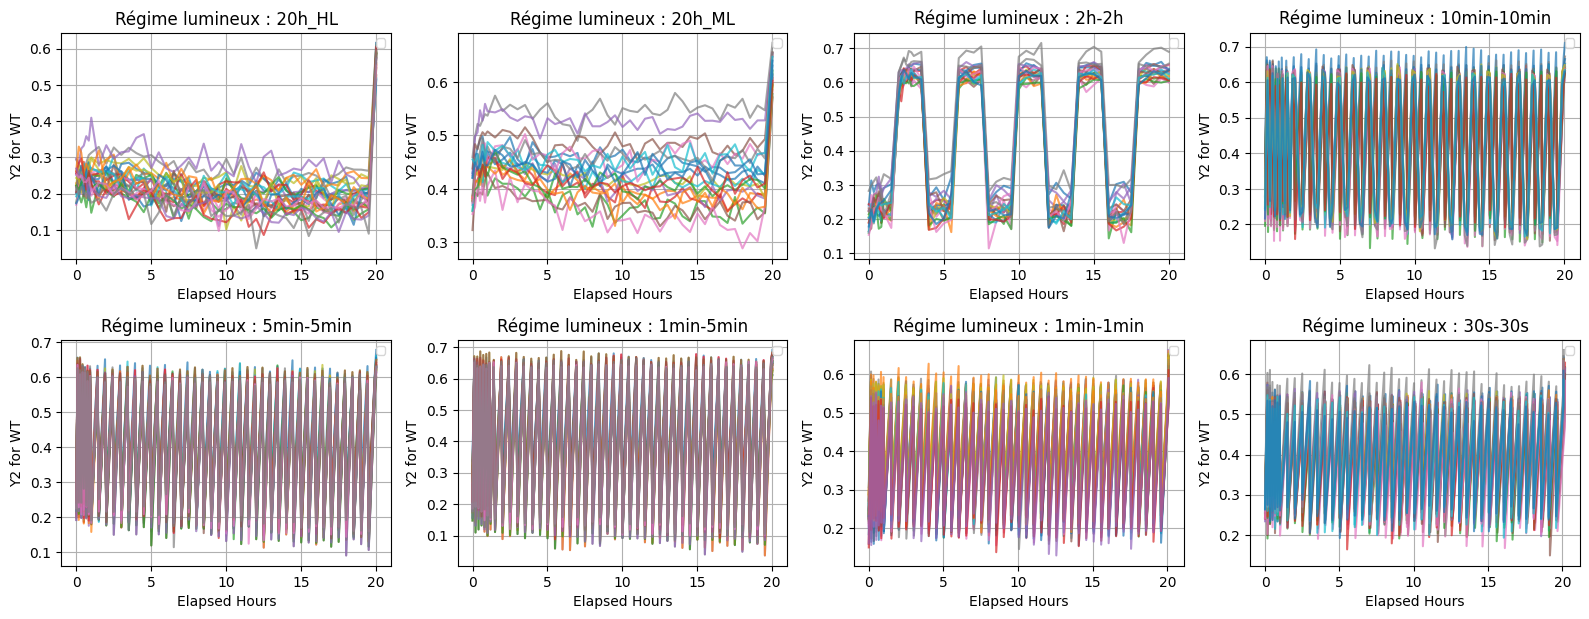

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/phase2_05_slopeWTsubtracted.csv')
y2_columns = [col for col in data.columns if col.startswith('y2_') and col.split('_')[-1].isdigit() and 'std' not in col]
time_columns = [col for col in data.columns if col.startswith('measurement_time_')]
print(time_columns)

for col in time_columns:
    data[col] = pd.to_datetime(data[col],format='mixed')

elapsed_hours = data[time_columns].apply(lambda row: (row - row.min()).dt.total_seconds() / 3600, axis=1)

elapsed_hours.columns = [f'elapsed_hours_{i}' for i in range(len(elapsed_hours.columns))]
data = pd.concat([data, elapsed_hours], axis=1)

light_regimes = ['20h_HL', '20h_ML', '2h-2h', '10min-10min', '5min-5min', '1min-5min', '1min-1min', '30s-30s']

fig, axes = plt.subplots(4, 4, figsize=(16, 12))  # 4x4 grille
axes = axes.flatten()  # Aplatir la grille pour un accès facile

# Tracer les graphiques pour chaque régime lumineux
for i, light in enumerate(light_regimes):
    ax = axes[i]  # Sélectionner l'axe correspondant
    data_light = data[(data['light_regime'] == light) & (data['plate'].astype(str).str.startswith('30'))]  # Filtrer les données pour le régime lumineux actuel
    
    # Tracer les courbes pour chaque plaque
    for plate in data_light['plate'].unique():
        data_plate = data_light[(data_light['mutant_ID'].isin(['WT', 'WT CLiP'])) & (data_light['plate'] == plate)]
        
        for _, row in data_plate.iterrows():
            y2_values = row[y2_columns].values  # Extraire les valeurs y2
            time_values = row[elapsed_hours.columns].astype(float).values

            valid_indices = ~np.isnan(time_values)
            time_values = time_values[valid_indices]
            y2_values = y2_values[:len(time_values)]  # Assurez-vous que y2_values a la même longueur que time_values
            time_values = time_values[:len(y2_values)]
            ax.plot(time_values, y2_values, alpha=0.7)#, label=f'Plate {plate}')
    
    # Ajouter des détails au graphique
    #axes[i].set_xlim(0, 5)
    ax.set_title(f'Régime lumineux : {light}')
    ax.set_xlabel('Elapsed Hours')
    ax.set_ylabel('Y2 for WT')
    ax.grid(True)
    ax.legend(fontsize='small', loc='upper right')

# Supprimer les axes inutilisés si moins de 16 régimes lumineux
for j in range(len(light_regimes), len(axes)):
    fig.delaxes(axes[j])

# Ajuster l'espacement entre les graphiques
plt.tight_layout()
plt.show()

### FEATURE CORRELATION

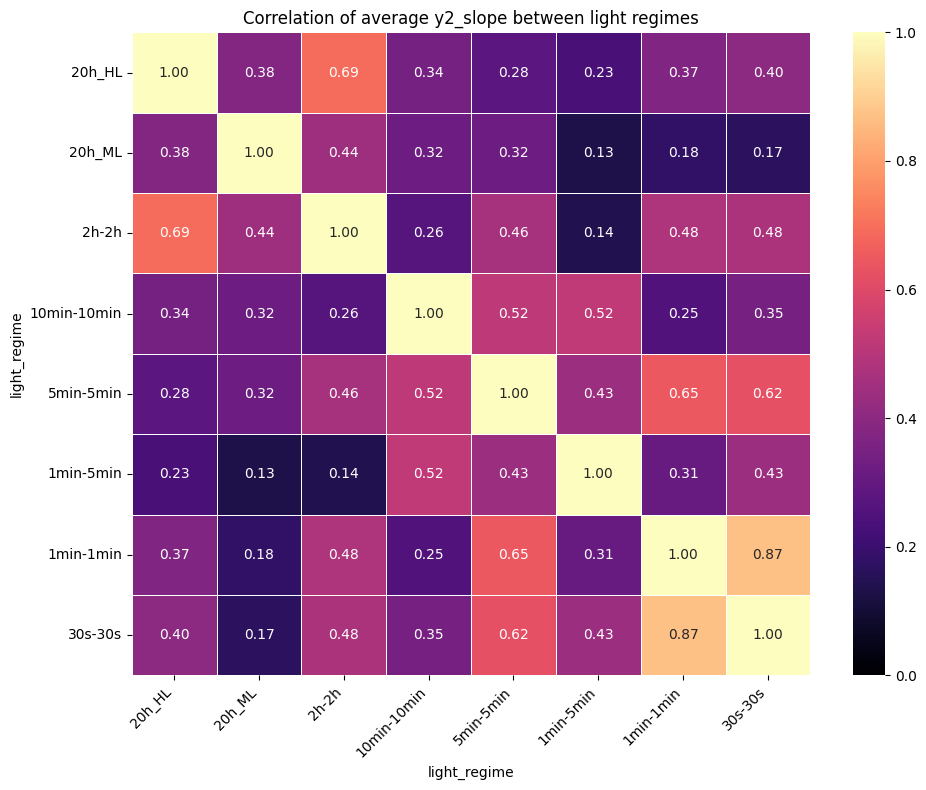

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your dataset (wide format: one slope column per regime)
data = pd.read_csv("/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_5_phase2_light_status_slope_COMBATT_randeff.csv")

# Pivot to wide format: one row per mutant_ID, one column per light regime
pivoted = data.pivot_table(
    index="mutant_ID",
    columns="light_regime",
    values="y2_slope",
    aggfunc="mean"
)
# Define desired light regime order
regime_order = [
    "20h_HL", "20h_ML", "2h-2h",
    "10min-10min", "5min-5min", "1min-5min", "1min-1min", "30s-30s"
]

# Reorder columns after pivot
pivoted = pivoted[regime_order]

# Drop rows with too many missing values (optional)
pivoted = pivoted.dropna(thresh=3)  # keep rows with at least 3 regimes

# Compute correlation
corr_matrix = pivoted.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap="magma", annot=True, fmt=".2f",
            vmin=0, vmax=1, linewidths=0.5)
plt.title("Correlation of average y2_slope between light regimes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### y2 slope trend per light frequency

In [5]:
#Myria's genes
high_freq= [
    'Cre03.g162701', 'Cre15.g635800', 'Cre01.g042352', 'Cre05.g235800', 'Cre16.g693600',
    'Cre16.g661200', 'Cre13.g588150', 'Cre16.g664150', 'Cre09.g386850', 'Cre06.g278110',
    'Cre02.g098750', 'Cre04.g228850', 'Cre12.g560668', 'Cre01.g009700', 'Cre03.g162701',
    'Cre14.g617800', 'Cre02.g105350', 'Cre10.g455231', 'Cre06.g259950'
]

high_light_freq = [
    'Cre10.g463300', 'Cre04.g232502', 'Cre06.g274400', 'Cre07.g323450', 'Cre08.g367350',
    'Cre13.g581900', 'Cre06.g295600', 'Cre09.g399663', 'Cre08.g358571', 'Cre07.g314800',
    'Cre06.g278219', 'Cre03.g168900', 'Cre05.g239850', 'Cre10.g430900', 'Cre16.g681600',
    'Cre17.g732533', 'Cre10.g453050', 'Cre12.g531900', 'Cre01.g024800'
]

high_light = [
    'Cre04.g215150', 'Cre17.g746397', 'Cre06.g285451', 'Cre04.g214501'
]


/tmp/ipykernel_359345/2874944197.py:71: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(mutants))


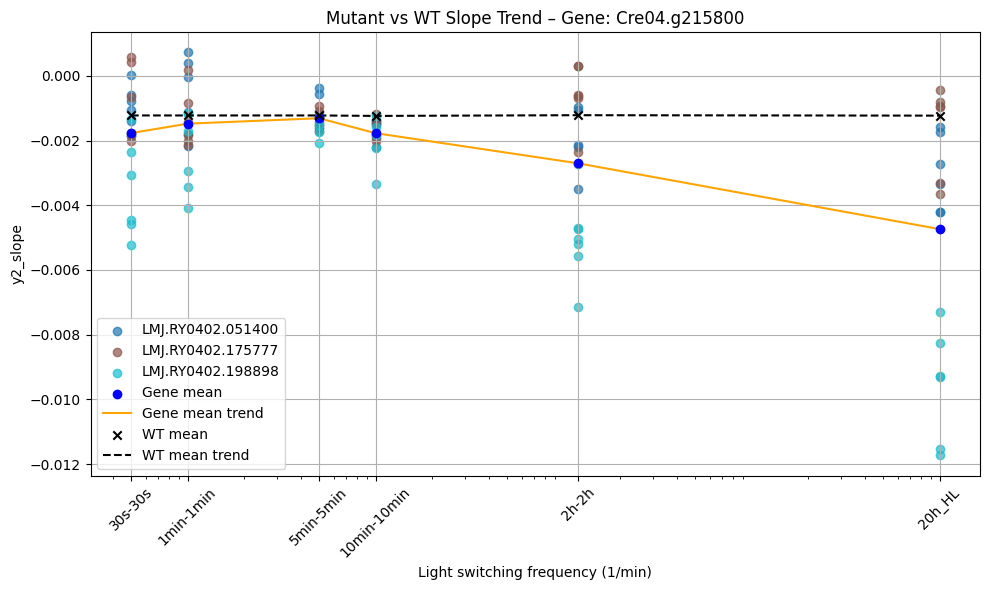


ANCOVA results for gene Cre04.g215800:

                  sum_sq     df          F        PR(>F)
freq            0.000039    1.0  24.469556  1.201704e-06
is_mutant       0.000088    1.0  55.331847  8.774581e-13
freq:is_mutant  0.000088    1.0  55.237082  9.144789e-13
Residual        0.000528  332.0        NaN           NaN


In [12]:
import numpy as np
import pandas as pd
from numpy.polynomial.polynomial import Polynomial
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Load data
data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_5_phase2_light_status_slope_COMBATT_randeff_slope_cluster_y2_p_valzscore.csv')

# Light regime order and frequency mapping
# regime_order = ['20h_HL', '20h_ML', '2h-2h', '10min-10min', '5min-5min', '1min-1min', '30s-30s']
# regime_to_freq = {regime: i / (len(regime_order) - 1) for i, regime in enumerate(regime_order)}

#  frequencies in 1/min
regime_to_freq = {
    '20h_HL': 10000,                     
    '2h-2h': 120,                
    '10min-10min': 10,          
    '5min-5min': 5,
    '1min-1min': 1,
    '30s-30s': 0.5           
}
regime_order = list(regime_to_freq.keys())

for gene in ['Cre04.g215800']:
    # if gene not in data['mutated_genes'].unique():
    #     print(f'{gene} not present in dataset')
    #     continue
    gene_data = data[
        (data['mutated_genes'].astype(str).str.contains(gene)) &
        (data['light_regime'].isin(regime_order)) &
        (~data['y2_slope'].isna())
    ].copy()
    gene_data['freq'] = gene_data['light_regime'].map(regime_to_freq)

    plates = gene_data['plate'].unique()
    wt_data = data[
        (data['mutated_genes'] == 'WT') &
        (data['plate'].isin(plates)) &
        (data['light_regime'].isin(regime_order)) &
        (~data['y2_slope'].isna())
    ].copy()
    wt_data['freq'] = wt_data['light_regime'].map(regime_to_freq)

    mutant_means = gene_data.groupby(['mutant_ID', 'light_regime']).agg(
        mean_y2_slope=('y2_slope', 'mean')
    ).reset_index()

    gene_agg = mutant_means.groupby('light_regime').agg(
        mean_y2_slope=('mean_y2_slope', 'mean')
    ).reset_index()

    gene_agg['freq'] = gene_agg['light_regime'].map(regime_to_freq)

    wt_agg = wt_data.groupby('light_regime').agg(
        mean_y2_slope=('y2_slope', 'mean')
    ).reset_index()
    wt_agg['freq'] = wt_agg['light_regime'].map(regime_to_freq)

    x_gene = gene_agg['freq'].values
    y_gene = gene_agg['mean_y2_slope'].values

    x_wt = wt_agg['freq'].values
    y_wt = wt_agg['mean_y2_slope'].values
    gene_agg = gene_agg.sort_values("freq")
    wt_agg = wt_agg.sort_values("freq")


    plt.figure(figsize=(10, 6))
    mutants = gene_data['mutant_ID'].unique()
    colors = cm.get_cmap('tab10', len(mutants)) 
    for i, mutant in enumerate(mutants):
        mutant_df = gene_data[gene_data['mutant_ID'] == mutant]
        plt.scatter(
            mutant_df['freq'],
            mutant_df['y2_slope'],
            label=mutant,
            color=colors(i),
            alpha=0.7
        )

    plt.xscale('log')

    plt.scatter(x_gene, y_gene, color='blue', label="Gene mean", zorder=3)
    plt.plot(gene_agg['freq'], gene_agg['mean_y2_slope'], color='orange', label="Gene mean trend", zorder=2)

    plt.scatter(x_wt, y_wt, color='black', label="WT mean", zorder=3, marker='x')
    plt.plot(wt_agg['freq'], wt_agg['mean_y2_slope'], color='black', linestyle='--', label="WT mean trend", zorder=1)

    # equidistant
    # plt.xticks(ticks=list(regime_to_freq.values()), labels=regime_order, rotation=45)
    # plt.xlabel("Light Regime (low to high frequency)")
    
    # freq scale
    plt.xticks(
        ticks=[regime_to_freq[r] for r in regime_order],
        labels=regime_order,
        rotation=45
    )
    plt.xlabel("Light switching frequency (1/min)")

    plt.ylabel("y2_slope")
    plt.title(f"Mutant vs WT Slope Trend – Gene: {gene}")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Combine WT and mutant data
gene_data['is_mutant'] = 1
wt_data['is_mutant'] = 0

combined_data = pd.concat([gene_data, wt_data], ignore_index=True)

# Fit the ANCOVA model
model = ols('y2_slope ~ freq * is_mutant', data=combined_data).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print(f"\nANCOVA results for gene {gene}:\n")
print(anova_table)


In [ ]:
import pandas as pd

# Load data
data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_5_phase2.csv')

# Identify relevant y2 columns (excluding std columns)
y2_columns = [col for col in data.columns if col.startswith('y2_') and 'std' not in col]

# Columns to keep
cols_to_keep = ['mutated_genes', 'light_regime', 'plate'] + y2_columns

# Apply filters
data = data[(data['plate'] == '30v2')]# | (data['plate'] == '31v1')]
data = data[(data['light_regime'] == '10min-10min') | (data['light_regime'] == '1min-1min')]
data = data[data['mutated_genes']=='Cre03.g171650']
# Subset to selected columns
data = data[cols_to_keep]

# Display result
data



/tmp/ipykernel_237682/2548180531.py:4: DtypeWarning: Columns (462,463) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_5_phase2.csv')


,mutated_genes,light_regime,plate,y2_1,y2_2,y2_3,y2_4,y2_5,y2_6,y2_7,...,y2_80,y2_81,y2_82,y2_83,y2_84,y2_85,y2_86,y2_87,y2_88,y2_89
3877,Cre03.g171650,1min-1min,30v2,0.213665,0.574978,0.191832,0.544836,0.222379,0.534424,0.229977,...,0.530479,0.252911,0.531076,0.233405,0.540094,0.189468,0.524928,0.175555,0.502240,NaN
4134,Cre03.g171650,1min-1min,30v2,0.201397,0.553209,0.166496,0.492567,0.191094,0.524146,0.162186,...,0.524086,0.169630,0.531782,0.161534,0.489813,0.212781,0.512189,0.169454,0.489744,NaN
4136,Cre03.g171650,1min-1min,30v2,0.176668,0.508013,0.150136,0.485818,0.126719,0.497530,0.145667,...,0.429083,0.074225,0.407204,0.126700,0.418532,0.140679,0.417310,0.102006,0.408848,NaN
5732,Cre03.g171650,10min-10min,30v2,0.287374,0.641615,0.219023,0.616510,0.224898,0.612082,0.200292,...,0.604670,0.167892,0.589770,0.195390,0.615918,0.197395,0.608169,0.221247,0.610178,NaN
5988,Cre03.g171650,10min-10min,30v2,0.223656,0.632406,0.240452,0.592308,0.189240,0.601579,0.185652,...,0.589154,0.182147,0.585917,0.178879,0.591071,0.188813,0.576834,0.185263,0.576628,NaN
5990,Cre03.g171650,10min-10min,30v2,0.143178,0.549932,0.121629,0.532977,0.140866,0.520356,0.154870,...,0.494700,0.063840,0.514987,0.063166,0.502931,0.066513,0.491859,0.066115,0.489264,NaN


/tmp/ipykernel_359345/2775208476.py:64: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab20', len(plates))


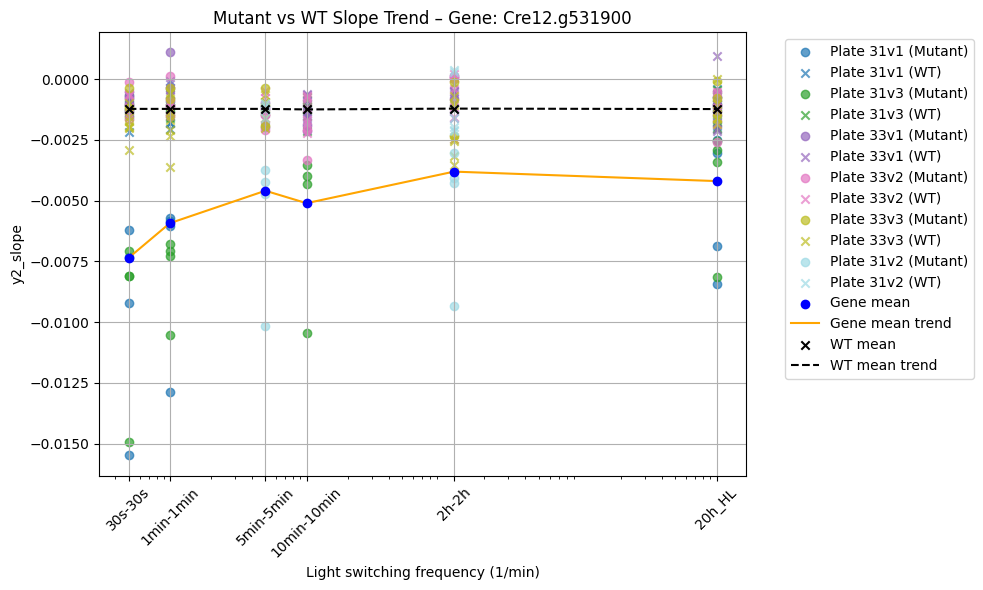

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from numpy.polynomial.polynomial import Polynomial
import matplotlib.cm as cm

# Load data
data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_5_phase2_light_status_slope_COMBATT_randeff_slope_cluster_y2_p_valzscore.csv')

# Frequencies
regime_to_freq = {
    '20h_HL': 10000,
    '2h-2h': 120,
    '10min-10min': 10,
    '5min-5min': 5,
    '1min-1min': 1,
    '30s-30s': 0.5
}
regime_order = list(regime_to_freq.keys())

for gene in ['Cre12.g531900']:
    gene_data = data[
        (data['mutated_genes'].astype(str).str.contains(gene)) &
        (data['light_regime'].isin(regime_order)) &
        (~data['y2_slope'].isna())
    ].copy()
    gene_data['freq'] = gene_data['light_regime'].map(regime_to_freq)

    plates = gene_data['plate'].unique()
    wt_data = data[
        (data['mutated_genes'] == 'WT') &
        (data['plate'].isin(plates)) &
        (data['light_regime'].isin(regime_order)) &
        (~data['y2_slope'].isna())
    ].copy()
    wt_data['freq'] = wt_data['light_regime'].map(regime_to_freq)

    # Mean of each mutant per light regime
    mutant_means = gene_data.groupby(['mutant_ID', 'light_regime']).agg(
        mean_y2_slope=('y2_slope', 'mean')
    ).reset_index()

    gene_agg = mutant_means.groupby('light_regime').agg(
        mean_y2_slope=('mean_y2_slope', 'mean')
    ).reset_index()
    gene_agg['freq'] = gene_agg['light_regime'].map(regime_to_freq)

    wt_agg = wt_data.groupby('light_regime').agg(
        mean_y2_slope=('y2_slope', 'mean')
    ).reset_index()
    wt_agg['freq'] = wt_agg['light_regime'].map(regime_to_freq)

    gene_agg = gene_agg.sort_values("freq")
    wt_agg = wt_agg.sort_values("freq")

    x_gene = gene_agg['freq'].values
    y_gene = gene_agg['mean_y2_slope'].values
    x_wt = wt_agg['freq'].values
    y_wt = wt_agg['mean_y2_slope'].values

    # === Plot ===
    plt.figure(figsize=(10, 6))

    colors = cm.get_cmap('tab20', len(plates))
    for i, plate in enumerate(plates):
        color = colors(i)
        plate_mutants = gene_data[gene_data['plate'] == plate]
        plate_wts = wt_data[wt_data['plate'] == plate]

        # Plot mutant points
        plt.scatter(
            plate_mutants['freq'],
            plate_mutants['y2_slope'],
            label=f'Plate {plate} (Mutant)',
            color=color,
            alpha=0.7
        )
        # Plot WT points from same plate
        plt.scatter(
            plate_wts['freq'],
            plate_wts['y2_slope'],
            label=f'Plate {plate} (WT)',
            color=color,
            alpha=0.7,
            marker='x'
        )

    # Mean & trend lines
    plt.scatter(x_gene, y_gene, color='blue', label="Gene mean", zorder=3)
    plt.plot(gene_agg['freq'], gene_agg['mean_y2_slope'], color='orange', label="Gene mean trend", zorder=2)

    plt.scatter(x_wt, y_wt, color='black', label="WT mean", zorder=3, marker='x')
    plt.plot(wt_agg['freq'], wt_agg['mean_y2_slope'], color='black', linestyle='--', label="WT mean trend", zorder=1)

    plt.xscale('log')
    plt.xticks(
        ticks=[regime_to_freq[r] for r in regime_order],
        labels=regime_order,
        rotation=45
    )
    plt.xlabel("Light switching frequency (1/min)")
    plt.ylabel("y2_slope")
    plt.title(f"Mutant vs WT Slope Trend – Gene: {gene}")
    plt.grid(True)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


In [6]:
# this code disappeared, here it is again
data_iqr = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/DifferentTestGenes/QTILNORM_randeffonTIMEPOINTS_IQR_outliers_light_blocs95%.csv')

# Combine your lists properly:
all_high_light_freq = set(high_light_freq)
all_high_light = set(high_light)
all_high_freq = set(high_freq)

# Function to classify each gene
def classify_gene(gene):
    if any(gene in high for high in all_high_light_freq):
        return 'high_light_freq'
    elif any(gene in high for high in all_high_light):
        return 'high_light'
    elif any(gene in high for high in all_high_freq):
        return 'high_freq'
    else:
        return 'other'

# Apply classification
data_iqr['myria_prediction'] = data_iqr['mutated_genes'].apply(classify_gene)
data_iqr.drop_duplicates(subset=['mutated_genes', 'light_regime'], inplace=True)
data_iqr.to_csv('whatever.csv', index=False)

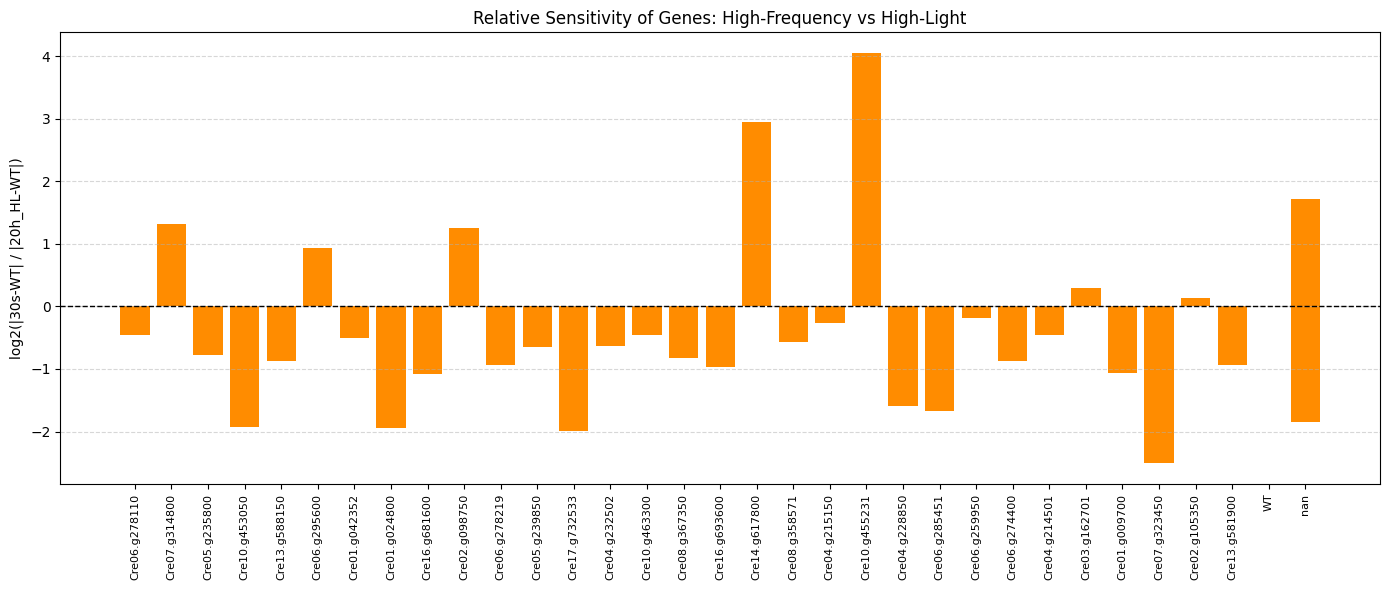

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_5_phase2_light_status_slope_COMBATT_randeff_slope_cluster_y2_p_valzscore.csv')

# List of genes to evaluate
genes = high_freq + high_light + high_light_freq + ['WT']

# Optional: fixed plotting order
custom_order = [
    'Cre06.g278110', 'Cre07.g314800', 'Cre05.g235800', 'Cre10.g453050', 'Cre13.g588150',
    'Cre06.g295600', 'Cre09.g99663', 'Cre01.g042352', 'Cre01.g024800', 'Cre16.g681600',
    'Cre12.g331900', 'Cre02.g098750', 'Cre06.g278219', 'Cre05.g239850', 'Cre17.g732533',
    'Cre04.g232502', 'Cre10.g463300', 'Cre08.g367350', 'Cre16.g693600', 'Cre09.g388650',
    'Cre14.g617800', 'Cre10.g439000', 'Cre08.g358571', 'Cre04.g215150', 'Cre12.g606668',
    'Cre10.g455231', 'Cre04.g228850', 'Cre06.g285451', 'Cre06.g259950',
    'Cre06.g274400', 'Cre04.g214501', 'Cre03.g162701', 'Cre01.g009700', 'Cre07.g323450',
    'Cre02.g105350', 'Cre13.g581900', 'WT'
]

# Precompute WT means
wt_data = data[data['mutated_genes'] == 'WT']
wt_means = wt_data.groupby('light_regime').agg(mean_y2_slope=('y2_slope', 'mean'))

ratios = []
epsilon = 1e-6  # small constant to avoid division by 0

for gene in genes:
    gene_data = data[(data['mutated_genes'].astype(str).str.contains(gene)) & (~data['y2_slope'].isna())]

    # Mean slope per light regime (replica-averaged mutants → mutant-averaged gene)
    mutant_means = gene_data.groupby(['mutant_ID', 'light_regime']).agg(
        mean_y2_slope=('y2_slope', 'mean')
    ).reset_index()

    gene_means = mutant_means.groupby('light_regime').agg(
        mean_y2_slope=('mean_y2_slope', 'mean')
    )

    if '30s-30s' in gene_means.index and '20h_HL' in gene_means.index:
        gene_FL = gene_means.loc['30s-30s', 'mean_y2_slope']
        gene_HL = gene_means.loc['20h_HL', 'mean_y2_slope']

        if '30s-30s' in wt_means.index and '20h_HL' in wt_means.index:
            wt_FL = wt_means.loc['30s-30s', 'mean_y2_slope']
            wt_HL = wt_means.loc['20h_HL', 'mean_y2_slope']

            dist_FL = np.abs(gene_FL - wt_FL)
            dist_HL = np.abs(gene_HL - wt_HL)

            # Compute log2 of distance ratio
            log_ratio = np.log2((dist_FL + epsilon) / (dist_HL + epsilon))
            ratios.append((gene, log_ratio))

# Convert to DataFrame
ratio_df = pd.DataFrame(ratios, columns=['gene', 'log2_FL_HL_ratio'])

# Sort by custom order
ratio_df['gene'] = pd.Categorical(ratio_df['gene'], categories=custom_order, ordered=True)
ratio_df = ratio_df.sort_values('gene')
ratio_df['gene'] = ratio_df['gene'].astype(str)

# Plot
plt.figure(figsize=(14, 6))
plt.bar(ratio_df['gene'], ratio_df['log2_FL_HL_ratio'], color='darkorange')
plt.xticks(rotation=90, fontsize=8)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.ylabel('log2(|30s-WT| / |20h_HL-WT|)')
plt.title('Relative Sensitivity of Genes: High-Frequency vs High-Light')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


### Plot all the outliers of IQR to see how good it is

In [35]:

data_iqr = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/DifferentTestGenes/QTILNORM_randeffonTIMEPOINTS_IQR_outliers_light_blocs95%.csv')
data_iqr.drop_duplicates(subset=['mutated_genes', 'light_regime'], inplace=True)
genes_30s = data_iqr[data_iqr['light_regime'] == '30s-30s']['mutated_genes'].unique()
genes_1min = data_iqr[data_iqr['light_regime'] == '1min-1min']['mutated_genes'].unique()
genes_HL = data_iqr[data_iqr['light_regime'] == '20h_HL']['mutated_genes'].unique()

FL_genes = set(pd.concat([pd.Series(genes_30s), pd.Series(genes_1min)]))
HL_genes = set(pd.Series(genes_HL))